#  DINOv2 on DESI Legacy Imaging Surveys DR10
**Self-Supervised ViTs for Unsupervised Object and Part Discovery**

In [6]:
!pip install -q datasets transformers accelerate scikit-learn umap-learn matplotlib

In [7]:
import numpy as np, matplotlib.pyplot as plt, torch, torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoModel, AutoImageProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, "|", torch.cuda.get_device_name(0) if device=="cuda" else "no GPU")
torch.manual_seed(0); np.random.seed(0)

Device: cuda | Tesla T4


In [8]:
DATASET = "MultimodalUniverse/legacysurvey"
CONFIG  = "default"
N_SAMPLES = 500

ds_stream = load_dataset(DATASET, CONFIG, split="train", streaming=True)
samples = []
for i, ex in enumerate(ds_stream):
    samples.append(ex)
    if len(samples) >= N_SAMPLES: break
print("Loaded", len(samples), "galaxies")
print("Keys:", list(samples[0].keys()))

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

Loaded 500 galaxies
Keys: ['image', 'blobmodel', 'rgb', 'object_mask', 'catalog', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'object_id']


In [9]:
ex = samples[0]
for k, v in ex.items():
    if isinstance(v, (list, tuple)):
        print(f"{k:15s} list(len={len(v)})  first item type: {type(v[0]).__name__}")
    elif isinstance(v, dict):
        print(f"{k:15s} dict keys={list(v.keys())}")
    else:
        print(f"{k:15s} {type(v).__name__}: {str(v)[:60]}")

image           dict keys=['band', 'flux', 'mask', 'ivar', 'psf_fwhm', 'scale']
blobmodel       PngImageFile: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x160
rgb             PngImageFile: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x160
object_mask     PngImageFile: <PIL.PngImagePlugin.PngImageFile image mode=L size=160x160 a
catalog         dict keys=['FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'TYPE', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'X', 'Y']
EBV             float: 0.06657393276691437
FLUX_G          float: 1.3640868663787842
FLUX_R          float: 2.831369161605835
FLUX_I          float: 4.151123523712158
FLUX_Z          float: 4.814830780029297
FLUX_W1         float: 9.40977954864502
FLUX_W2         float: 7.014428615570068
FLUX_W3         float: 78.4160385131836
FLUX_W4         float: -49.9306755065918
SHAPE_R         float: 0.9420995116233826
SHAPE_E1        float: 0.23311986029148102
SHAPE_E2        float: -0.33112043142318726
object_id       str: b'0421p

In [10]:
DATASET = "MultimodalUniverse/legacysurvey"
CONFIG  = "default"
N_SAMPLES = 500

ds_stream = load_dataset(DATASET, CONFIG, split="train", streaming=True)
samples = []
for i, ex in enumerate(ds_stream):
    samples.append(ex)
    if len(samples) >= N_SAMPLES: break
print("Loaded", len(samples), "galaxies")
print("Keys:", list(samples[0].keys()))

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

Loaded 500 galaxies
Keys: ['image', 'blobmodel', 'rgb', 'object_mask', 'catalog', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'object_id']


In [11]:
def get_bands(ex):
    img = ex["image"]
    if isinstance(img, dict):
        names, flux = img["band"], img["flux"]
    else:
        names, flux = [d["band"] for d in img], [d["flux"] for d in img]
    return {str(n)[-1].lower(): np.asarray(f, dtype=np.float32) for n, f in zip(names, flux)}

b = get_bands(samples[0])
print({k: v.shape for k, v in b.items()})
for k, v in b.items():
    print(k, "min %.3f  max %.3f  mean %.3f" % (v.min(), v.max(), v.mean()))

{'g': (160, 160), 'r': (160, 160), 'i': (160, 160), 'z': (160, 160)}
g min -0.007  max 0.021  mean 0.000
r min -0.011  max 0.054  mean 0.000
i min -0.029  max 0.090  mean 0.000
z min -0.037  max 0.115  mean 0.000


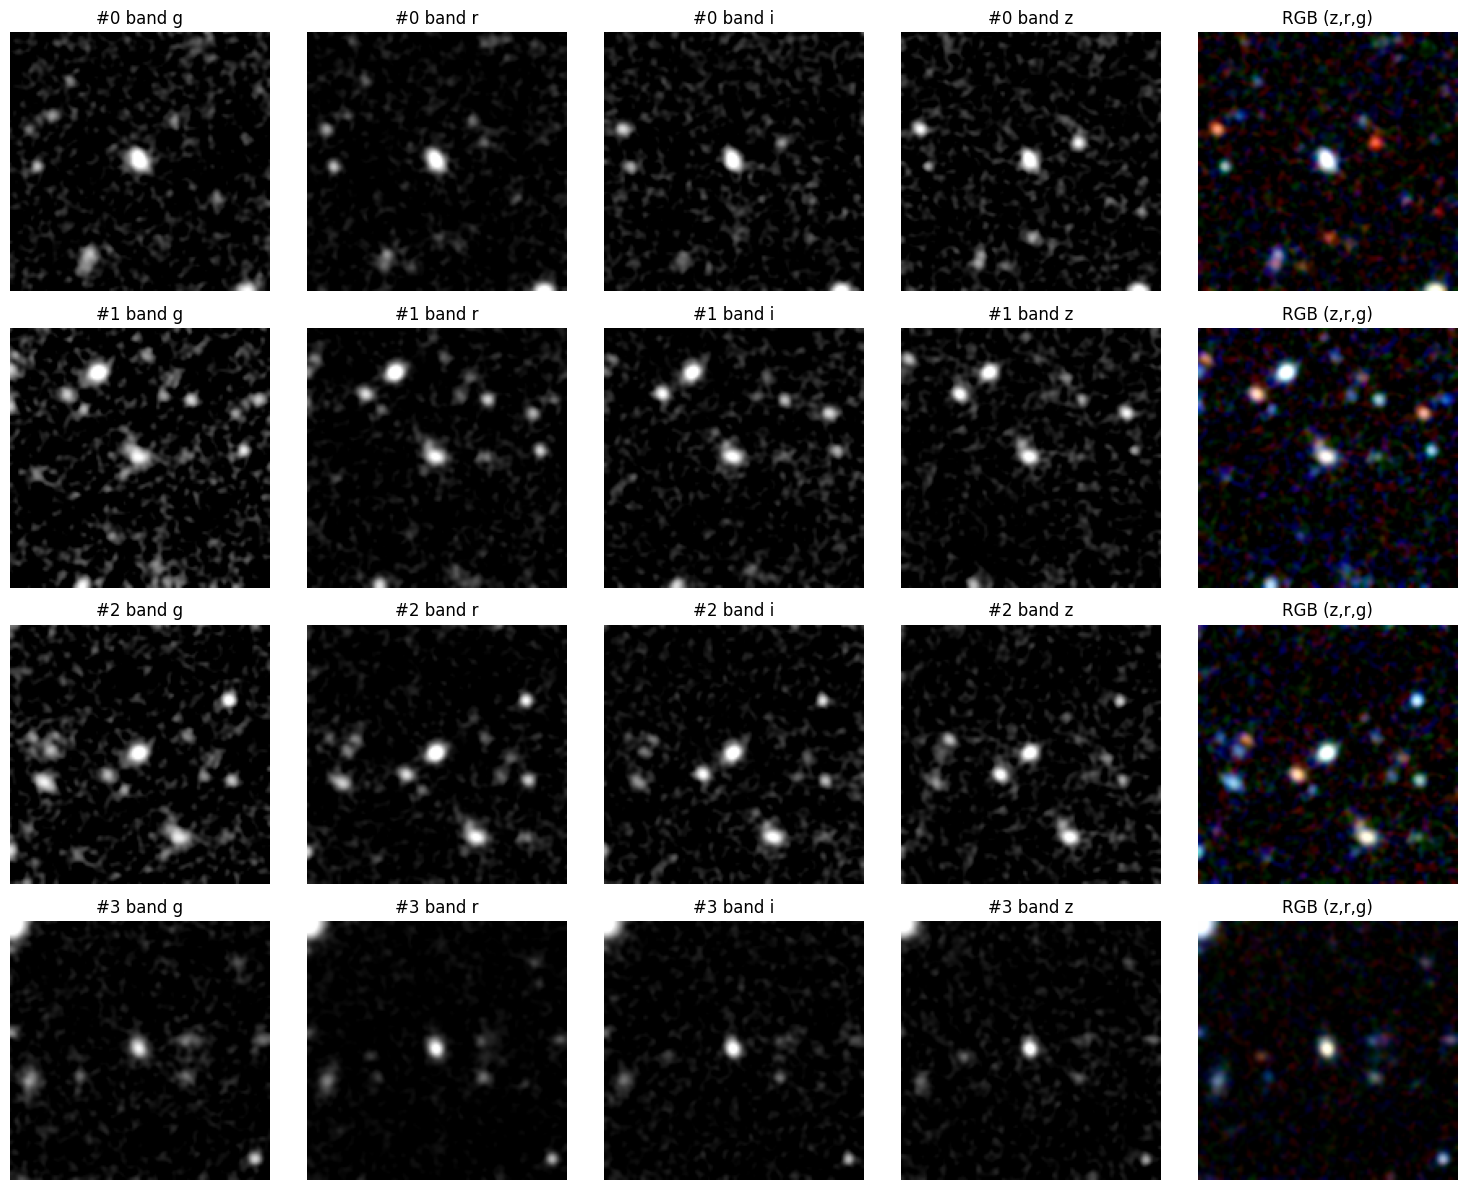

In [12]:
from scipy.ndimage import gaussian_filter

def stretch(x, soft=0.2):
    x = gaussian_filter(x, 1.5)
    bg = np.median(x)
    hi = np.percentile(x, 99.8)
    x = np.clip((x - bg) / (hi - bg + 1e-8), 0, 1)
    return np.arcsinh(x / soft) / np.arcsinh(1 / soft)

def make_rgb(bands, order=("z", "r", "g")):
    """Map (z,r,g) -> (R,G,B): redder = longer wavelength."""
    chans = [stretch(bands[k]) for k in order]
    return np.stack(chans, -1).astype(np.float32)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for row, idx in enumerate(range(4)):
    bands = get_bands(samples[idx])
    for col, bn in enumerate(["g", "r", "i", "z"]):
        axes[row, col].imshow(stretch(bands[bn]), cmap="gray"); axes[row, col].set_title(f"#{idx} band {bn}")
        axes[row, col].axis("off")
    axes[row, 4].imshow(make_rgb(bands)); axes[row, 4].set_title("RGB (z,r,g)"); axes[row, 4].axis("off")
plt.tight_layout(); plt.show()

In [13]:
import pandas as pd, os
LABELS_PATH = "/content/galaxy_zoo_labels.csv"

if os.path.exists(LABELS_PATH):
    labels = pd.read_csv(LABELS_PATH)
    print(labels.shape)
    display(labels.head())
    print("\nColumns:\n", list(labels.columns))
else:
    labels = None
    print("Label file not found. Upload it and update LABELS_PATH. Continuing without labels.")

Label file not found. Upload it and update LABELS_PATH. Continuing without labels.


In [14]:

if labels is not None:
    frac_cols = [c for c in labels.columns if "fraction" in c.lower() or c.lower().endswith("_frac")]
    print("Vote-fraction columns:", len(frac_cols))
    for c in frac_cols[:6]:
        plt.figure(figsize=(4,2.5)); labels[c].hist(bins=30); plt.title(c); plt.show()

In [15]:
MODEL_NAME = "facebook/dinov2-small"
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()
print(processor)
print("Hidden size:", model.config.hidden_size, "| layers:", model.config.num_hidden_layers,
      "| heads:", model.config.num_attention_heads, "| patch:", model.config.patch_size)

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

BitImageProcessor {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "BitImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 256
  }
}

Hidden size: 384 | layers: 12 | heads: 6 | patch: 14


In [16]:
from PIL import Image

def to_pil(ex):
    rgb = (make_rgb(get_bands(ex)) * 255).astype(np.uint8)
    return Image.fromarray(rgb)

MEAN = torch.tensor(processor.image_mean).view(1,3,1,1)
STD  = torch.tensor(processor.image_std).view(1,3,1,1)

def preprocess(pil_list, size=224):
    arr = np.stack([np.asarray(p.resize((size, size), Image.BICUBIC)) for p in pil_list]).astype(np.float32) / 255.
    x = torch.from_numpy(arr).permute(0,3,1,2)
    return ((x - MEAN) / STD)

x = preprocess([to_pil(samples[0])])
print("Input tensor:", x.shape, "| mean %.2f std %.2f" % (x.mean(), x.std()))

Input tensor: torch.Size([1, 3, 224, 224]) | mean -1.76 std 0.48


In [17]:
@torch.no_grad()
def run_dino(x):
    out = model(pixel_values=x.to(device))
    return out.last_hidden_state.cpu()

tokens = run_dino(x)
print("last_hidden_state:", tokens.shape)

last_hidden_state: torch.Size([1, 257, 384])


In [18]:
cls_tok = tokens[:, 0]
print("CLS token:", cls_tok.shape)
print("First 8 values:", cls_tok[0, :8].numpy().round(3))
print("L2 norm: %.2f" % cls_tok[0].norm())

CLS token: torch.Size([1, 384])
First 8 values: [-2.152 -1.1    1.671  0.015  1.29   2.235  3.843 -1.836]
L2 norm: 49.66


In [19]:
patch_tok = tokens[:, 1:]
n = patch_tok.shape[1]; g = int(n ** 0.5)
print("Patch tokens:", patch_tok.shape, f"-> {g}x{g} grid")
patch_grid = patch_tok.reshape(1, g, g, -1)
print("Reshaped to grid:", patch_grid.shape)

Patch tokens: torch.Size([1, 256, 384]) -> 16x16 grid
Reshaped to grid: torch.Size([1, 16, 16, 384])


In [20]:
print(f"""
Input image        : 160x160 (4 bands) -> RGB -> resized to 224x224
Patch size         : {model.config.patch_size}x{model.config.patch_size}
Patch grid         : {g}x{g} = {n} patches
Tokens per image   : {n} patch + 1 CLS = {n+1}
Embedding dim      : {model.config.hidden_size}
last_hidden_state  : (batch, {n+1}, {model.config.hidden_size})
CLS embedding      : (batch, {model.config.hidden_size})
Patch embeddings   : (batch, {n}, {model.config.hidden_size})
""")
with torch.no_grad():
    out = model(pixel_values=x.to(device), output_hidden_states=True, output_attentions=False)
print("Number of hidden states (embeddings + layers):", len(out.hidden_states))
print("Each:", out.hidden_states[0].shape)


Input image        : 160x160 (4 bands) -> RGB -> resized to 224x224
Patch size         : 14x14
Patch grid         : 16x16 = 256 patches
Tokens per image   : 256 patch + 1 CLS = 257
Embedding dim      : 384
last_hidden_state  : (batch, 257, 384)
CLS embedding      : (batch, 384)
Patch embeddings   : (batch, 256, 384)

Number of hidden states (embeddings + layers): 13
Each: torch.Size([1, 257, 384])


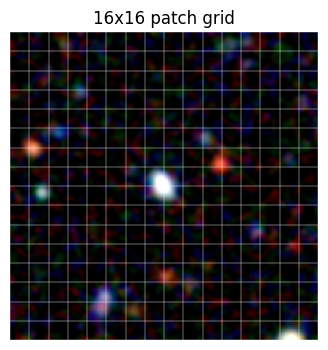

In [21]:
from sklearn.decomposition import PCA

def show_patch_grid(ex, size=224, g=16):
    img = to_pil(ex).resize((size, size))
    fig, ax = plt.subplots(figsize=(4,4)); ax.imshow(img)
    step = size / g
    for k in range(g + 1):
        ax.axhline(k*step-0.5, color="w", lw=0.3); ax.axvline(k*step-0.5, color="w", lw=0.3)
    ax.set_title(f"{g}x{g} patch grid"); ax.axis("off"); plt.show()

show_patch_grid(samples[0])

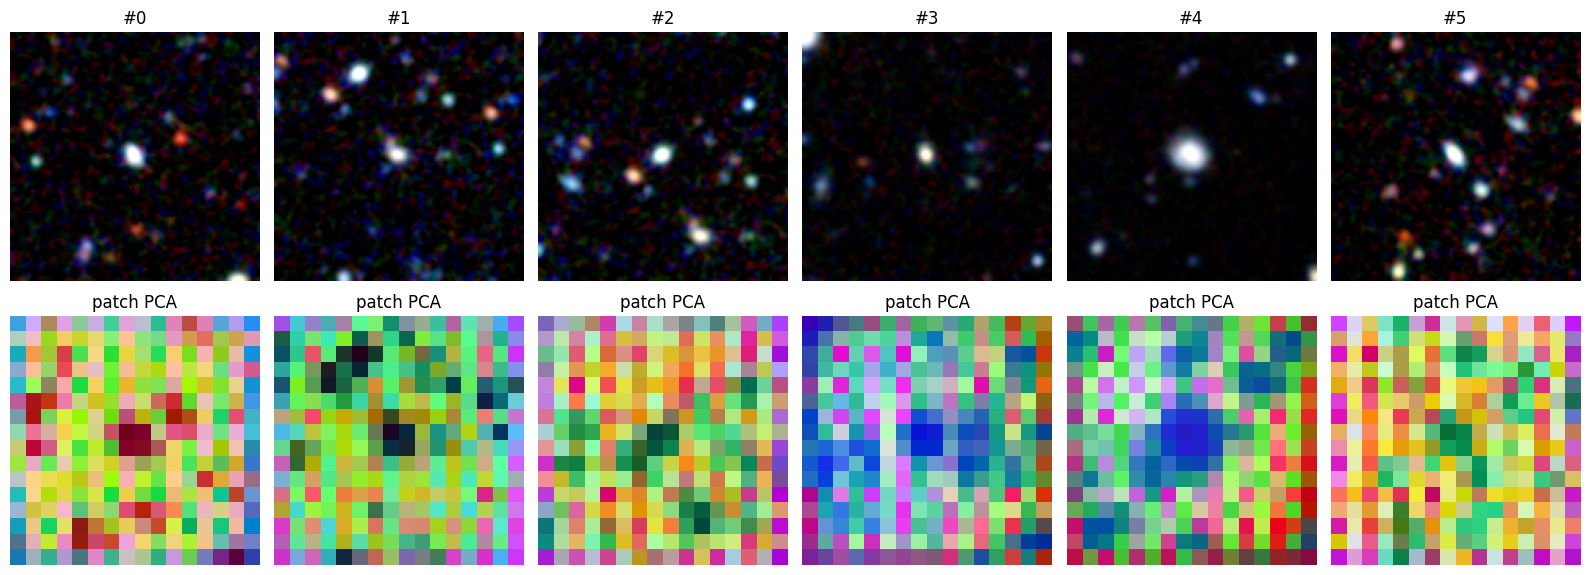

In [22]:
def pca_patch_map(ex):
    x = preprocess([to_pil(ex)])
    t = run_dino(x)[0, 1:]
    comp = PCA(n_components=3).fit_transform(t.numpy())
    comp = (comp - comp.min(0)) / (comp.max(0) - comp.min(0) + 1e-8)
    return comp.reshape(16, 16, 3)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for j, i in enumerate(range(6)):
    axes[0, j].imshow(make_rgb(get_bands(samples[i]))); axes[0, j].axis("off"); axes[0, j].set_title(f"#{i}")
    axes[1, j].imshow(pca_patch_map(samples[i])); axes[1, j].axis("off"); axes[1, j].set_title("patch PCA")
plt.tight_layout(); plt.show()

In [23]:
@torch.no_grad()
def embed_all(exs, bs=32):
    cls_list = []
    for i in range(0, len(exs), bs):
        x = preprocess([to_pil(e) for e in exs[i:i+bs]])
        cls_list.append(run_dino(x)[:, 0])
    return torch.cat(cls_list).numpy()

emb = embed_all(samples)
print("Embeddings:", emb.shape)

Embeddings: (500, 384)


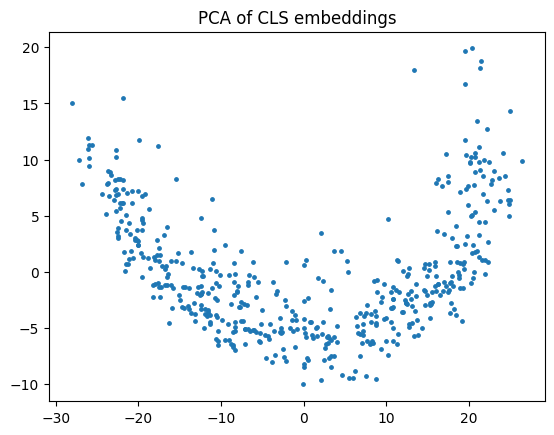

In [24]:

from sklearn.manifold import TSNE
p2 = PCA(n_components=2).fit_transform(emb)
plt.scatter(*p2.T, s=6); plt.title("PCA of CLS embeddings"); plt.show()

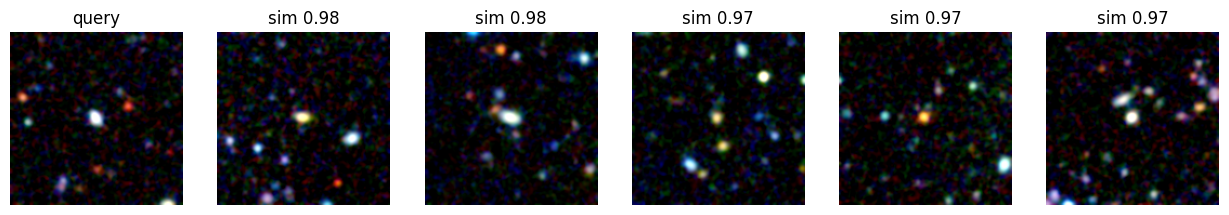

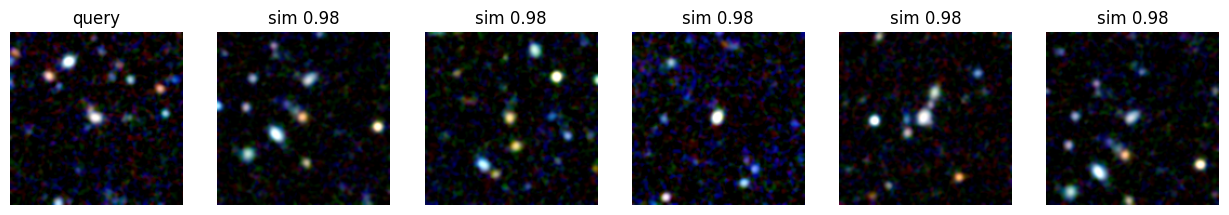

In [25]:

embn = emb / np.linalg.norm(emb, axis=1, keepdims=True)
def show_neighbors(q, k=5):
    sims = embn @ embn[q]
    nn = np.argsort(-sims)[:k+1]
    fig, axes = plt.subplots(1, k+1, figsize=(2.6*(k+1), 3))
    for ax, i in zip(axes, nn):
        ax.imshow(make_rgb(get_bands(samples[i]))); ax.axis("off")
        ax.set_title("query" if i == q else f"sim {sims[i]:.2f}")
    plt.show()

for q in [0, 1]: show_neighbors(q)